In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import pprint

In [3]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM

In [4]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x711a201babf0>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x711a20030ac0>, root_client=<openai.OpenAI object at 0x711a2111eef0>, root_async_client=<openai.AsyncOpenAI object at 0x711a201bac20>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the Graph state

State is the object that is passed between nodes in the graph.

In [5]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, AnyMessage # type: ignore
import operator
from IPython.display import Image, display

In [6]:
class AgentState(TypedDict):
    input: str
    agent_outcome: List[AnyMessage]
    chat_history: Annotated[list, operator.add]

The `AgentState` schema represents the structure and type of data that graph will use.


`TypeDict` is a Python dictionary subclass that allows to specify keys and their corresponding value types. These can be used for type-checking, however they are not enforced at runtime. 

If validation is required, use `BaseClass` from `Pydantic`

### Define the agent (node)

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant. Given a user query, answer the question."
                " Use chat summary only for previous context."
                "\nUser Query: {input}"
            ),
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    agent = prompt | llm
    result = agent.invoke(data)
    return {
                'agent_outcome': [result],
                'chat_history': ["User: " + data['input'] + "\n AI Message: " + result.content],
            }

### Defining the workflow (graph)

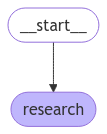

In [8]:
from langgraph.graph import END, StateGraph

## Initialising the workflow
workflow = StateGraph(AgentState)

## Adding node (agent) to the graph (workflow)
workflow.add_node("research", research_agent)

## Setting the entry point of the graph
workflow.set_entry_point("research")

## Compiling the graph
app = workflow.compile()
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Streaming Output

`.stream` and `.astream` are sync and async methods for streaming back outputs from a graph run.

Reference: [langgraph streaming](https://langchain-ai.github.io/langgraph/concepts/streaming/)

In [9]:
inputs = {
    "input": "What are Small Language Models?",
}
for step in app.stream(inputs, stream_mode="updates"):
    print(step)

{'research': {'agent_outcome': [AIMessage(content='Small Language Models are artificial intelligence models designed to understand and generate human language, but they are smaller in size and complexity compared to larger models like GPT-3 or GPT-4. These models typically have fewer parameters, which makes them faster and less resource-intensive to run. They can be used for various tasks such as text generation, translation, summarization, and more, but may not perform as well as larger models on complex tasks due to their limited capacity. Small Language Models are often preferred in applications where computational efficiency and speed are critical, or when deploying models on devices with limited resources.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 40, 'total_tokens': 159, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}

`updates` This streams the updates to the state after each step of the graph. If multiple updates are made in the same step (e.g. multiple nodes are run) then those updates are streamed separately.

Each `step` is a dictionary, where keys are `node_name` and values are the updated states.

In [10]:
for step in app.stream(inputs, stream_mode="updates"):
    for msg in step['research']['agent_outcome']:
        msg.pretty_print()

================================== Ai Message ==================================

Small Language Models are artificial intelligence models designed to understand and generate human language, but they are smaller in size and complexity compared to larger models like GPT-3 or GPT-4. These models typically have fewer parameters, which makes them faster and less resource-intensive to run. They can be used for various tasks such as text generation, translation, summarization, and more, but may not perform as well as larger models on complex tasks due to their limited capacity. Small Language Models are often preferred in applications where computational efficiency and speed are critical, or when deploying models on devices with limited resources.


In [11]:
from langchain_core.messages import HumanMessage

inputs = {
    "input": "What are Small Language Models?",
}

for step in app.stream(inputs, stream_mode="values"):
    try:
        for msg in step['agent_outcome']:
            msg.pretty_print()
    except:
        HumanMessage(inputs["input"]).pretty_print()

================================ Human Message =================================

What are Small Language Models?
================================== Ai Message ==================================

Small Language Models are artificial intelligence models designed to understand and generate human language, but they are smaller in size and complexity compared to larger models like GPT-3 or GPT-4. These models typically have fewer parameters, which makes them faster and less resource-intensive to run. They can be used for various tasks such as text generation, translation, summarization, and more, but may not perform as well as larger models on complex tasks due to their limited capacity. Small Language Models are often preferred in applications where computational efficiency and speed are critical, or when deploying models on devices with limited resources.


`values` This streams the full value of the state after each step of the graph.

### Streaming and Chatbot

In [12]:
from langchain_core.messages import AIMessage

def stream_app_updates(user_input: str, chat_history: list):
    inputs = {
        "input": user_input,
        "chat_history": chat_history
    }
    for event in app.stream(input=inputs):
        for value in event.values():
            response = value["agent_outcome"]
            conv = value["chat_history"][-1]
            
    return response, conv

chat_history = []
while True:
    user_input = input("User: ")
    HumanMessage(user_input).pretty_print()
    if user_input.lower() in ["quit", "exit", "q"]:
        AIMessage("Goodbye!").pretty_print()
        break

    response, conv = stream_app_updates(user_input, chat_history)
     
    for msg in response:
        msg.pretty_print()
    chat_history.append(conv)

================================ Human Message =================================

Hello I am Sam Ctrlman
================================== Ai Message ==================================

Hello Sam Ctrlman! How can I assist you today?
================================ Human Message =================================

What are GPT models?
================================== Ai Message ==================================

GPT models, or Generative Pre-trained Transformers, are a type of artificial intelligence language model developed by OpenAI. They are designed to understand and generate human-like text based on the input they receive. These models are pre-trained on a diverse range of internet text and can perform various language tasks, such as answering questions, writing essays, summarizing information, and more. The "transformer" architecture allows them to process and generate text efficiently, making them powerful tools for natural language processing.
===============================